In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Load the updated spatial dataset
DATASET_PATH = "/content/drive/MyDrive/AI_Crime_Prediction/datasets/Bengaluru_Spatial.csv"
df = pd.read_csv(DATASET_PATH)

# Ensure Date is in datetime format
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Grid_ID", "Date"])

print("Data loaded and sorted. Total events:", len(df))

Mounted at /content/drive
Data loaded and sorted. Total events: 147769


/tmp/ipykernel_5798/986178929.py:8: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


In [ ]:
# Decay parameter (controls how quickly the influence of a crime fades)
BETA = 0.1

df["Hawkes_Intensity"] = 0.0

# Process each Grid separately
for grid in df["Grid_ID"].unique():
    grid_data = df[df["Grid_ID"] == grid].copy()
    grid_data = grid_data.sort_values("Date")
    dates = grid_data["Date"].values

    intensities = []
    for i in range(len(dates)):
        # Calculate time difference in days for all previous crimes
        delta_days = (dates[i] - dates[:i]).astype('timedelta64[D]').astype(int)
        # Sum the exponential decay
        intensity = np.sum(np.exp(-BETA * delta_days))
        intensities.append(intensity)

    df.loc[grid_data.index, "Hawkes_Intensity"] = intensities

print("Hawkes Intensity Calculated Successfully!")

Hawkes Intensity Calculated Successfully!


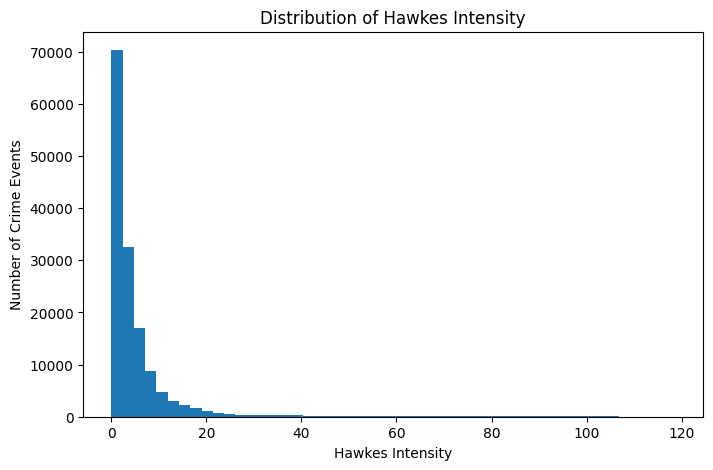

Bengaluru_Hawkes.csv Saved Successfully!


In [ ]:
import matplotlib.pyplot as plt
import os

# Check the distribution to see if '5' is a good threshold
plt.figure(figsize=(8,5))
plt.hist(df["Hawkes_Intensity"], bins=50)
plt.title("Distribution of Hawkes Intensity")
plt.xlabel("Hawkes Intensity")
plt.ylabel("Number of Crime Events")
plt.show()

# Save the final file
SAVE_PATH = "/content/drive/MyDrive/AI_Crime_Prediction/datasets"
df.to_csv(f"{SAVE_PATH}/Bengaluru_Hawkes.csv", index=False)
print("Bengaluru_Hawkes.csv Saved Successfully!")